# Worksheet 5 Solution

## Problem 1: Data Load and EDA

In [3]:
import pandas as pd

project = pd.read_csv("projectSN.csv")
project

,projectid,teacheracctid,schoolid,primary_focus_subject,primary_focus_area,secondary_focus_subject,secondary_focus_area,resource_type,poverty_level,grade_level,...,students_reached,total_donations,num_donors,eligible_double_your_impact_match,eligible_almost_home_match,funding_status,date_posted,date_completed,date_thank_you_packet_mailed,date_expiration
0,5208,1831,750,Special Needs,Special Needs,Literacy,Literacy & Language,Technology,highest poverty,Grades 3-5,...,12.0,423.18,1,0,0,completed,2004-09-11 00:00:00,2006-11-22 00:00:00,2007-05-03 00:00:00,2005-05-11 00:00:00
1,5417,1523,523,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,moderate poverty,Grades PreK-2,...,750.0,0.00,0,0,0,expired,2004-09-21 00:00:00,NaN,NaN,2005-05-21 00:00:00
2,5704,2057,572,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades PreK-2,...,25.0,142.00,1,0,0,completed,2004-10-13 00:00:00,2004-10-25 00:00:00,2004-12-01 00:00:00,2005-01-01 00:00:00
3,5891,2156,294,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades 3-5,...,30.0,283.00,1,0,0,completed,2004-10-26 00:00:00,2004-11-01 00:00:00,2004-12-10 00:00:00,2005-06-26 00:00:00
4,5917,2169,851,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades 3-5,...,13.0,479.55,2,0,0,completed,2004-10-28 00:00:00,2005-01-11 00:00:00,2005-04-01 00:00:00,2005-06-28 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78879,1203187,104486,1404,Special Needs,Special Needs,College & Career Prep,Applied Learning,Technology,highest poverty,Grades 3-5,...,675.0,0.00,0,0,0,live,2016-10-11 00:00:00,NaN,NaN,2017-02-08 00:00:00
78880,1203225,423643,50154,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades 3-5,...,10.0,0.00,0,0,0,live,2016-10-11 00:00:00,NaN,NaN,2017-02-06 00:00:00
78881,1203234,423646,72905,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades PreK-2,...,18.0,50.00,1,0,0,live,2016-10-11 00:00:00,NaN,NaN,2017-02-10 00:00:00
78882,1203245,305907,10441,Special Needs,Special Needs,Health & Wellness,Health & Sports,Supplies,high poverty,Grades 3-5,...,4.0,0.00,0,0,0,live,2016-10-11 00:00:00,NaN,NaN,2017-02-10 00:00:00


In [5]:
# Check funding status
project["funding_status"].isna().sum()

0

In [7]:
project["funding_status"].value_counts()

funding_status
completed      52166
expired        21789
live            4360
reallocated      569
Name: count, dtype: int64

Nontrivial number of live projects that we will need to handle.

In [10]:
essay = pd.read_csv("essaySN.csv")
essay

,essayid,projectid,teacheracctid,title,short_description,need_statement,essay,thankyou_note,impact_letter
0,12,739877,240944,Give Us Aids!,I have a 6:1:1 classroom of children with Auti...,My students need lots of materials that need t...,I have a 6:1:1 classroom of children with Auti...,NaN,NaN
1,15,856466,162657,Learning With Technology!,My students are wonderful! They come to school...,My students need an iPad mini to help develop ...,My students are wonderful! They come to schoo...,Thank you so much for your generous donation. ...,THANK YOU! THANK YOU! THANK YOU!!!I would like...
2,33,520023,195959,Small Group Instruction,My students need a space where they can receiv...,My students need a kidney shape table where th...,My students need a space where they can receiv...,Thank you for your contribution to our project...,Thank you for your generous donation. The ta...
3,40,883599,323894,"""Be The Change You Want To See In The World""(G...","""So often you find that the students you're tr...",My students need 1 Numbers & Letters Activity ...,"""So often you find that the students you're tr...",Thank you so much ! I can't speak for my stude...,Thank You so much for your donations. Our rug ...
4,60,375333,137150,Visual Timers For The Classroom,We need the large visual timer to help student...,My students need 3 visual timers to see time p...,We need the large visual timer to help student...,<br>Thank you for your generous donation t...,Thank you again for your generosity. The sand ...
...,...,...,...,...,...,...,...,...,...
78870,1203077,1202703,421198,iSense Learning,Our school has mostly have students that quali...,"My students need tablets, a tech tub and wobbl...",Our school has mostly have students that quali...,NaN,NaN
78871,1203079,503660,31498,Beyond the Classroom,Using technology to enhance learning is an inc...,My students need a laptop to access different ...,Using technology to enhance learning is an inc...,NaN,NaN
78872,1203080,1156139,60467,Wiggle and Wobble for Learning- Part 2,Kids like to move. If you have ever spent any ...,My students need 10 Hokki Wobble Stools to sup...,Kids like to move. If you have ever spent any ...,Thank you so very much for supporting my proje...,NaN
78873,1203092,587431,222412,Seeking to Bridge Gap with Apps,My students are challenged with profound physi...,My students need the touch screen and endless ...,My students are challenged with profound physi...,"I can't fully express my joy, excitement, and ...","I can't fully express my joy, excitement, and ..."


In [12]:
essay.isna().sum()

essayid                  0
projectid                0
teacheracctid            0
title                    0
short_description        3
need_statement           0
essay                    1
thankyou_note        26854
impact_letter        36834
dtype: int64

One essay missing and neither of the other two; should be fine to label. Let's check sizes to get a sense of data scale.

<Axes: >

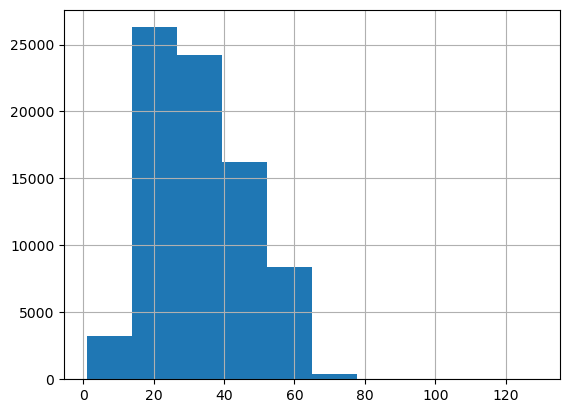

In [15]:
essay["title"].str.len().hist()

<Axes: >

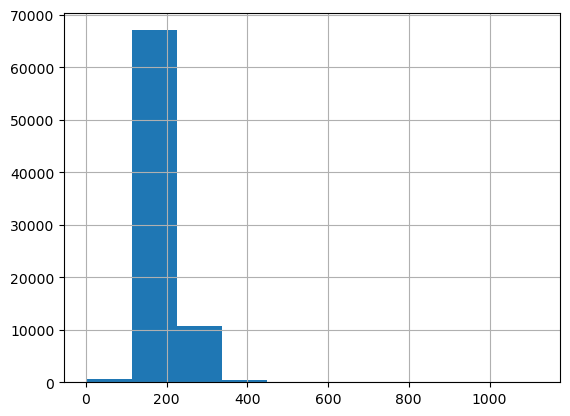

In [17]:
essay["short_description"].str.len().hist()

<Axes: >

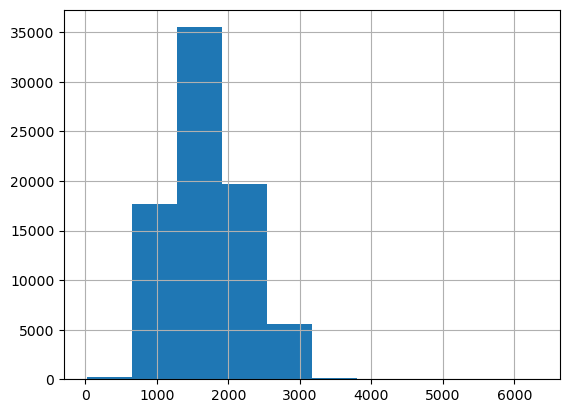

In [19]:
essay["essay"].str.len().hist()

Quite different scales in terms of length. Should give a good feel for the tool capabilities.

## Problem 2: Vader score for each column
Key function vaderScore loaded from the setup document.

In [32]:
## All copied from setup document::

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
import nltk.data

analyzer = SentimentIntensityAnalyzer()
tokenizer = nltk.data.load('tokenizers/punkt/PY3/english.pickle')

def vaderScore(text):
    if pd.isna(text):
        return 0.0
    sentences = tokenizer.tokenize(text)
    scores = [analyzer.polarity_scores(s)["compound"] for s in sentences]
    return sum(scores)/len(scores)

In [34]:
essay["title_vader"] = essay["title"].apply(vaderScore)
essay["short_vader"] = essay["short_description"].apply(vaderScore)
essay["essay_vader"] = essay["essay"].apply(vaderScore)
essay

,essayid,projectid,teacheracctid,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader
0,12,739877,240944,Give Us Aids!,I have a 6:1:1 classroom of children with Auti...,My students need lots of materials that need t...,I have a 6:1:1 classroom of children with Auti...,NaN,NaN,0.0000,0.013800,0.206390
1,15,856466,162657,Learning With Technology!,My students are wonderful! They come to school...,My students need an iPad mini to help develop ...,My students are wonderful! They come to schoo...,Thank you so much for your generous donation. ...,THANK YOU! THANK YOU! THANK YOU!!!I would like...,0.0000,0.308025,0.243367
2,33,520023,195959,Small Group Instruction,My students need a space where they can receiv...,My students need a kidney shape table where th...,My students need a space where they can receiv...,Thank you for your contribution to our project...,Thank you for your generous donation. The ta...,0.0000,0.064267,0.093206
3,40,883599,323894,"""Be The Change You Want To See In The World""(G...","""So often you find that the students you're tr...",My students need 1 Numbers & Letters Activity ...,"""So often you find that the students you're tr...",Thank you so much ! I can't speak for my stude...,Thank You so much for your donations. Our rug ...,0.0772,0.664900,0.387314
4,60,375333,137150,Visual Timers For The Classroom,We need the large visual timer to help student...,My students need 3 visual timers to see time p...,We need the large visual timer to help student...,<br>Thank you for your generous donation t...,Thank you again for your generosity. The sand ...,0.0000,0.042900,0.183008
...,...,...,...,...,...,...,...,...,...,...,...,...
78870,1203077,1202703,421198,iSense Learning,Our school has mostly have students that quali...,"My students need tablets, a tech tub and wobbl...",Our school has mostly have students that quali...,NaN,NaN,0.0000,0.482075,0.268063
78871,1203079,503660,31498,Beyond the Classroom,Using technology to enhance learning is an inc...,My students need a laptop to access different ...,Using technology to enhance learning is an inc...,NaN,NaN,0.0000,-0.019850,0.150517
78872,1203080,1156139,60467,Wiggle and Wobble for Learning- Part 2,Kids like to move. If you have ever spent any ...,My students need 10 Hokki Wobble Stools to sup...,Kids like to move. If you have ever spent any ...,Thank you so very much for supporting my proje...,NaN,0.0000,0.195675,0.428556
78873,1203092,587431,222412,Seeking to Bridge Gap with Apps,My students are challenged with profound physi...,My students need the touch screen and endless ...,My students are challenged with profound physi...,"I can't fully express my joy, excitement, and ...","I can't fully express my joy, excitement, and ...",0.0000,-0.220200,0.264510


<Axes: >

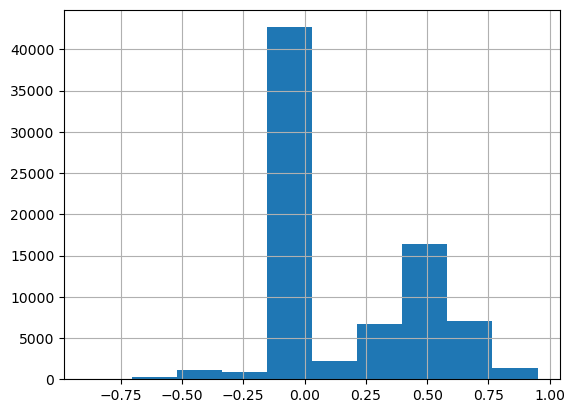

In [37]:
essay["title_vader"].hist()

<Axes: >

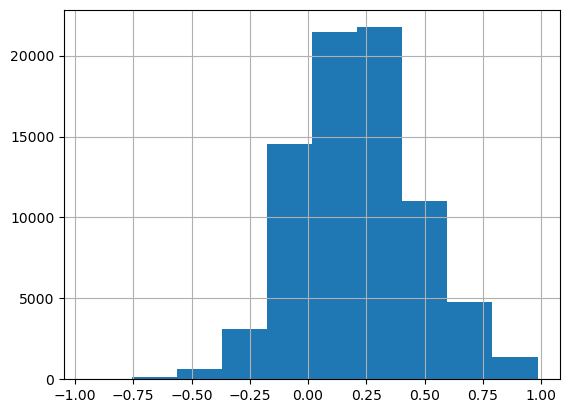

In [39]:
essay["short_vader"].hist()

<Axes: >

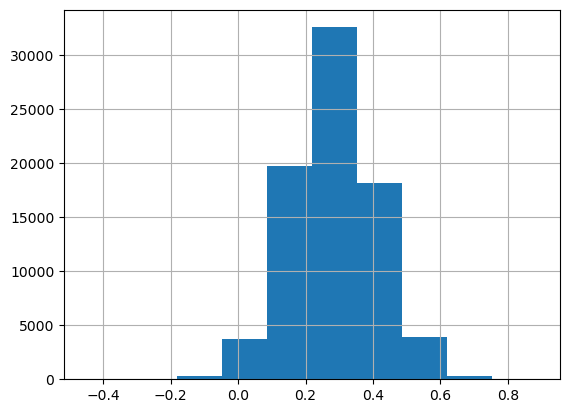

In [41]:
essay["essay_vader"].hist()

In [43]:
essay.isna().sum()

essayid                  0
projectid                0
teacheracctid            0
title                    0
short_description        3
need_statement           0
essay                    1
thankyou_note        26854
impact_letter        36834
title_vader              0
short_vader              0
essay_vader              0
dtype: int64

We got a score for all the text, and the distributions show these tend to be positive, but some much more than others. Lots of 0 scores for titles (maybe because they are short).

## Problem 3: Analyze funding status as a function of sentiment. 
We will need to merge our two data frames and summarize sentiment versus funding status. I'll focus on essay sentiment.

We had 78884 project and 78875 essays; let's do our normal checks to make sure this merge goes through well.

In [49]:
project["projectid"].duplicated().sum()

0

In [51]:
essay["projectid"].duplicated().sum()

0

In [63]:
merged = pd.merge(project, essay, on="projectid", how="inner")
merged

,projectid,teacheracctid_x,schoolid,primary_focus_subject,primary_focus_area,secondary_focus_subject,secondary_focus_area,resource_type,poverty_level,grade_level,...,teacheracctid_y,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader
0,5208,1831,750,Special Needs,Special Needs,Literacy,Literacy & Language,Technology,highest poverty,Grades 3-5,...,1831,Nintendo Video Games in My Class??,I am the Bilingual Special Education teacher f...,"The cost of a Nintendo GameCube, Memory Card, ...",I am the Bilingual Special Education teacher f...,Thank you so much for taking your time and rea...,NaN,0.0000,0.100475,0.260389
1,5417,1523,523,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,moderate poverty,Grades PreK-2,...,1523,Let's Get Poppin',The valuable hands on learning experiences fro...,"The cost of a popcorn machine and cart, popcor...",This proposal is to fund a popcorn stand run b...,NaN,NaN,0.0000,0.801050,0.457700
2,5704,2057,572,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades PreK-2,...,2057,Computer help!,I am a second year teacher and this year I was...,The cost of four pairs of Koss Collagpsible He...,I am a second year teacher and this year I was...,I would like to thank you for the gift of the ...,NaN,0.4574,0.000000,0.088412
3,5891,2156,294,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades 3-5,...,2156,Free to Breathe,I am a 5th grade teacher currently working in ...,"The cost of an LG 10,000 BTU air conditioner f...",I am a 5th grade teacher currently working in ...,Thank you very much for funding this proposal....,NaN,0.5106,0.113150,0.140336
4,5917,2169,851,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades 3-5,...,2169,A Space of our Own,"Dear Friend,<br /> I have been a special edu...","The cost of an area rug is $508, including shi...","Dear Friend,\n\n I have been a special educa...",Thank you so much for funding my request. Car...,NaN,0.0000,0.790600,0.317460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78870,1203043,422977,67187,Special Needs,Special Needs,NaN,NaN,Supplies,high poverty,Grades PreK-2,...,422977,Printer for an Autism Support Classoom,My class is full of visual learners who love t...,My students need a Canon All-in-one color prin...,My class is full of visual learners who love t...,NaN,NaN,0.4019,0.589233,0.435314
78871,1203062,423591,14022,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,highest poverty,Grades 6-8,...,423591,Stress? Ain't Nobody Got Time Fo Dat!!,My students are from a 70% poverty level and a...,My students need unconventional items to meet ...,My students are from a 70% poverty level and a...,NaN,NaN,-0.1405,-0.624900,-0.259337
78872,1203154,351448,35709,Special Needs,Special Needs,Health & Wellness,Health & Sports,Supplies,high poverty,Grades PreK-2,...,351448,Learning Tools for Room 204!,14 second grade students in room 204 need your...,"My students need sensory headphones, fidgets, ...",14 second grade students in room 204 need your...,NaN,NaN,0.0000,0.152467,0.367769
78873,1203180,252125,2658,Special Needs,Special Needs,NaN,NaN,Supplies,high poverty,Grades PreK-2,...,252125,Sensory Experience Leads to a Better Day,I am currently teaching a group of eight charm...,My students need a sand table and a water tabl...,I am currently teaching a group of eight charm...,NaN,NaN,0.4404,0.413550,0.275100


In [65]:
merged.isna().sum()

projectid                                     0
teacheracctid_x                               0
schoolid                                      0
primary_focus_subject                         0
primary_focus_area                            0
secondary_focus_subject                   26697
secondary_focus_area                      26697
resource_type                                 0
poverty_level                                 0
grade_level                                   2
vendor_shipping_charges                    1411
sales_tax                                  1411
payment_processing_charges                 1411
fulfillment_labor_materials                1411
total_price_excluding_optional_support        0
total_price_including_optional_support        0
students_reached                             12
total_donations                               0
num_donors                                    0
eligible_double_your_impact_match             0
eligible_almost_home_match              

OK, so basically we have 78884 projects, but 9 are missing all the written materials. This is very small missingness that should not impact our final results. I got the number of rows I expected when I joined my data.

There are many ways to break down continuous sentiment data into categories. I'll try "top 10" vs. "bottom 10" versus "middle 80".

In [67]:
merged["essay_sentiment"] = "middle 80"
merged.loc[merged["essay_vader"] >= merged["essay_vader"].quantile(0.9), "essay_sentiment"] = "top 10"
merged.loc[merged["essay_vader"] <= merged["essay_vader"].quantile(0.1), "essay_sentiment"] = "bottom 10"
merged

,projectid,teacheracctid_x,schoolid,primary_focus_subject,primary_focus_area,secondary_focus_subject,secondary_focus_area,resource_type,poverty_level,grade_level,...,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader,essay_sentiment
0,5208,1831,750,Special Needs,Special Needs,Literacy,Literacy & Language,Technology,highest poverty,Grades 3-5,...,Nintendo Video Games in My Class??,I am the Bilingual Special Education teacher f...,"The cost of a Nintendo GameCube, Memory Card, ...",I am the Bilingual Special Education teacher f...,Thank you so much for taking your time and rea...,NaN,0.0000,0.100475,0.260389,middle 80
1,5417,1523,523,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,moderate poverty,Grades PreK-2,...,Let's Get Poppin',The valuable hands on learning experiences fro...,"The cost of a popcorn machine and cart, popcor...",This proposal is to fund a popcorn stand run b...,NaN,NaN,0.0000,0.801050,0.457700,top 10
2,5704,2057,572,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades PreK-2,...,Computer help!,I am a second year teacher and this year I was...,The cost of four pairs of Koss Collagpsible He...,I am a second year teacher and this year I was...,I would like to thank you for the gift of the ...,NaN,0.4574,0.000000,0.088412,bottom 10
3,5891,2156,294,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades 3-5,...,Free to Breathe,I am a 5th grade teacher currently working in ...,"The cost of an LG 10,000 BTU air conditioner f...",I am a 5th grade teacher currently working in ...,Thank you very much for funding this proposal....,NaN,0.5106,0.113150,0.140336,middle 80
4,5917,2169,851,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades 3-5,...,A Space of our Own,"Dear Friend,<br /> I have been a special edu...","The cost of an area rug is $508, including shi...","Dear Friend,\n\n I have been a special educa...",Thank you so much for funding my request. Car...,NaN,0.0000,0.790600,0.317460,middle 80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78870,1203043,422977,67187,Special Needs,Special Needs,NaN,NaN,Supplies,high poverty,Grades PreK-2,...,Printer for an Autism Support Classoom,My class is full of visual learners who love t...,My students need a Canon All-in-one color prin...,My class is full of visual learners who love t...,NaN,NaN,0.4019,0.589233,0.435314,middle 80
78871,1203062,423591,14022,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,highest poverty,Grades 6-8,...,Stress? Ain't Nobody Got Time Fo Dat!!,My students are from a 70% poverty level and a...,My students need unconventional items to meet ...,My students are from a 70% poverty level and a...,NaN,NaN,-0.1405,-0.624900,-0.259337,bottom 10
78872,1203154,351448,35709,Special Needs,Special Needs,Health & Wellness,Health & Sports,Supplies,high poverty,Grades PreK-2,...,Learning Tools for Room 204!,14 second grade students in room 204 need your...,"My students need sensory headphones, fidgets, ...",14 second grade students in room 204 need your...,NaN,NaN,0.0000,0.152467,0.367769,middle 80
78873,1203180,252125,2658,Special Needs,Special Needs,NaN,NaN,Supplies,high poverty,Grades PreK-2,...,Sensory Experience Leads to a Better Day,I am currently teaching a group of eight charm...,My students need a sand table and a water tabl...,I am currently teaching a group of eight charm...,NaN,NaN,0.4404,0.413550,0.275100,middle 80


In [69]:
merged["essay_sentiment"].value_counts()

essay_sentiment
middle 80    63099
top 10        7888
bottom 10     7888
Name: count, dtype: int64

Plan -- remove all live projects and then compute the funding status rate in each sentiment group.

In [72]:
merged["funding_status"].value_counts()

funding_status
completed      52166
expired        21789
live            4351
reallocated      569
Name: count, dtype: int64

In [74]:
finished = merged[merged["funding_status"] != "live"].copy()
finished

,projectid,teacheracctid_x,schoolid,primary_focus_subject,primary_focus_area,secondary_focus_subject,secondary_focus_area,resource_type,poverty_level,grade_level,...,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader,essay_sentiment
0,5208,1831,750,Special Needs,Special Needs,Literacy,Literacy & Language,Technology,highest poverty,Grades 3-5,...,Nintendo Video Games in My Class??,I am the Bilingual Special Education teacher f...,"The cost of a Nintendo GameCube, Memory Card, ...",I am the Bilingual Special Education teacher f...,Thank you so much for taking your time and rea...,NaN,0.0000,0.100475,0.260389,middle 80
1,5417,1523,523,Special Needs,Special Needs,Character Education,Applied Learning,Supplies,moderate poverty,Grades PreK-2,...,Let's Get Poppin',The valuable hands on learning experiences fro...,"The cost of a popcorn machine and cart, popcor...",This proposal is to fund a popcorn stand run b...,NaN,NaN,0.0000,0.801050,0.457700,top 10
2,5704,2057,572,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades PreK-2,...,Computer help!,I am a second year teacher and this year I was...,The cost of four pairs of Koss Collagpsible He...,I am a second year teacher and this year I was...,I would like to thank you for the gift of the ...,NaN,0.4574,0.000000,0.088412,bottom 10
3,5891,2156,294,Special Needs,Special Needs,NaN,NaN,Technology,highest poverty,Grades 3-5,...,Free to Breathe,I am a 5th grade teacher currently working in ...,"The cost of an LG 10,000 BTU air conditioner f...",I am a 5th grade teacher currently working in ...,Thank you very much for funding this proposal....,NaN,0.5106,0.113150,0.140336,middle 80
4,5917,2169,851,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades 3-5,...,A Space of our Own,"Dear Friend,<br /> I have been a special edu...","The cost of an area rug is $508, including shi...","Dear Friend,\n\n I have been a special educa...",Thank you so much for funding my request. Car...,NaN,0.0000,0.790600,0.317460,middle 80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78789,1202104,423216,33384,Special Needs,Special Needs,NaN,NaN,Supplies,highest poverty,Grades PreK-2,...,Help My Students Control Their Movement and Im...,"I work at a Title 1 school in New Castle, Dela...",My students need these wobble chairs and stres...,"I work at a Title 1 school in New Castle, Del...",Thank you so much for your generosity toward m...,NaN,0.7088,-0.022033,0.177773,middle 80
78792,1202171,390683,9964,Special Needs,Special Needs,Health & Wellness,Health & Sports,Supplies,moderate poverty,Grades 6-8,...,Silence is Golden!,The students at D.H.S. come from very low soci...,My students need chair socks to help reduce un...,The students at D.H.S. come from very low soci...,Thank you so much for investing in the academi...,NaN,0.0000,-0.112800,0.026150,bottom 10
78802,1202280,423291,12202,Special Needs,Special Needs,Health & Wellness,Health & Sports,Supplies,highest poverty,Grades 6-8,...,Materials Needed For Active Engagement.,I teach 6th grade Science in North Carolina. O...,"My students need ink for interactive journals,...",I teach 6th grade Science in North Carolina. O...,NaN,NaN,0.6908,0.085000,0.193188,middle 80
78816,1202414,423345,52154,Special Needs,Special Needs,NaN,NaN,Supplies,high poverty,Grades 3-5,...,Smart Spots: How Do We Learn Best?,"My fifth graders are an active, motivated grou...","My students need a standing desk, stability di...","My fifth graders are an active, motivated grou...",WOW! Thank you so much for supporting my fifth...,NaN,0.7845,0.350667,0.348918,middle 80


In [76]:
finished["funding_status"].value_counts()

funding_status
completed      52166
expired        21789
reallocated      569
Name: count, dtype: int64

In [78]:
finished["funded"] = finished["funding_status"] == "completed"
finished["funded"].value_counts()

funded
True     52166
False    22358
Name: count, dtype: int64

In [82]:
finished.groupby("essay_sentiment").agg({"funded": ["mean", "count"]})

funded       
                     mean  count
essay_sentiment                 
bottom 10        0.695544   7607
middle 80        0.698605  59772
top 10           0.716305   7145

We see a subtle effect. Let's write up a sample paragraph:

We studied the effect of the writing style of Donors Choose essays on whether they eventually get funded. We focused our analysis on Donors Choose projects for special needs students, focusing on the 74,524 such projects where we can observe in our historical data whether the project got funded or not. For each project, we labeled how positive the language was in essay using an approach that assigns a "positivity score" to each word in the essay and then averages those stores to determine overall how positive it was. We found only subtle effects of writing style --- projects with the 10% most positive text were funded 71.6% of the time, compared to a 69.6% funding rate among the projects with the 10% least positive essay text and a 69.9% funding rate among the projects in between these two extremes.

## Problem 4: Hand-Labeling to Increase Confidence

Basically we're asking the students to:
* Randomly sample 20 projects
* Two team members hand-label sentiment for the project short descriptions
* Correlate the two human scores
* Correlate the average human score with the Vader score.

Let's do this task below, except we'll just randomly sample the human scores (this is the part we asked them to do by hand).

In [89]:
randomRows = essay.sample(20, random_state=144).copy()
randomRows

,essayid,projectid,teacheracctid,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader
2166,33808,413926,158980,Materials for Hands-On Learning,My students face a variety of learning challen...,My students need hands on centers and manipula...,My students face a variety of learning challen...,Thank you so much for your generous contributi...,Thank you so much for your generosity. My stu...,0.0000,0.378533,0.362667
31553,480195,1010473,365678,Special Needs Carpet and Therapy Tools,"""My heart is singing this morning. A miracle h...",My students need a carpet to define personal s...,"""My heart is singing this morning. A miracle h...",I have great news! My project has been fully ...,NaN,0.4019,0.474425,0.380862
6816,104208,1138726,403822,Culturally Relevant Tools For Exceptional 21st...,My students are diverse learners who are creat...,My students need Chromebooks to further their ...,My students are diverse learners who are creat...,Thank you so much for your generosity! I can't...,NaN,0.0000,0.256233,0.273600
2663,41547,887346,325234,"When Students Feel Comfortable, Learning Happens",The most common question I get is... where on ...,My students need chairs that are more comforta...,The most common question I get is... where on ...,NaN,NaN,0.5106,0.280767,0.105114
44540,676580,577172,78988,Learning Language With Die Cuts In Special Edu...,Did you ever consider how children with disabi...,"My students need an ink pad, 9 die cutter shap...",Did you ever consider how children with disabi...,I am so excited to see this project funded so ...,"""I want a turn!"" ""Is it my turn yet?"" ""Please,...",-0.5267,-0.067433,0.183623
73671,1125127,1164487,411149,Wiggle Worms: Seating that Moves With You!,Welcome to a classroom of wiggle worms! \n\nMy...,My students need Hokki stools for seating that...,Welcome to a classroom of wiggle worms! \n\nMy...,NaN,NaN,0.0000,0.090033,0.320500
50187,763491,747328,64075,Organization and Comfort,My students have needs that are drastically di...,My students need three bean bags and four stor...,My students have needs that are drastically di...,Thank you so very much for your generosity and...,NaN,0.3612,-0.032533,-0.084620
48039,729669,315633,46640,Classroom Organization Makeover,Organization is the key to success. Much learn...,"My students need organizational supplies, such...",Organization is the key to success. Much learn...,Thank you so much for your generous donations ...,"Thank you all so very, very much for your kind...",0.0000,0.192967,0.042800
9872,150077,916463,334187,Dunlap Middle School,A typical day in my classroom is working with ...,My students need 2 iPads to use the program Dr...,A typical day in my classroom is working with ...,NaN,NaN,0.0000,0.000000,0.216746
26401,401695,904061,287214,Furniture for Students With the Wiggles,I have always felt that students need to be ab...,My students need active seating furniture to a...,I have always felt that students need to be ab...,Thank you so very much for your very generous ...,Thank you so much for your generous donation! ...,0.0000,0.312450,0.365589


In [97]:
##### This is the part where they need to actually do the hand-labeling, but we'll just randomly assign.
from numpy.random import default_rng

rng = np.random.default_rng(seed=144) 
randomRows["human1"] = rng.uniform(low=-1, high=1, size=20)
randomRows["human2"] = rng.uniform(low=-1, high=1, size=20)
randomRows

,essayid,projectid,teacheracctid,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader,human1,human2
2166,33808,413926,158980,Materials for Hands-On Learning,My students face a variety of learning challen...,My students need hands on centers and manipula...,My students face a variety of learning challen...,Thank you so much for your generous contributi...,Thank you so much for your generosity. My stu...,0.0000,0.378533,0.362667,0.585524,0.451578
31553,480195,1010473,365678,Special Needs Carpet and Therapy Tools,"""My heart is singing this morning. A miracle h...",My students need a carpet to define personal s...,"""My heart is singing this morning. A miracle h...",I have great news! My project has been fully ...,NaN,0.4019,0.474425,0.380862,-0.880625,-0.124384
6816,104208,1138726,403822,Culturally Relevant Tools For Exceptional 21st...,My students are diverse learners who are creat...,My students need Chromebooks to further their ...,My students are diverse learners who are creat...,Thank you so much for your generosity! I can't...,NaN,0.0000,0.256233,0.273600,-0.400650,-0.830226
2663,41547,887346,325234,"When Students Feel Comfortable, Learning Happens",The most common question I get is... where on ...,My students need chairs that are more comforta...,The most common question I get is... where on ...,NaN,NaN,0.5106,0.280767,0.105114,-0.815757,-0.509923
44540,676580,577172,78988,Learning Language With Die Cuts In Special Edu...,Did you ever consider how children with disabi...,"My students need an ink pad, 9 die cutter shap...",Did you ever consider how children with disabi...,I am so excited to see this project funded so ...,"""I want a turn!"" ""Is it my turn yet?"" ""Please,...",-0.5267,-0.067433,0.183623,-0.408618,0.289448
73671,1125127,1164487,411149,Wiggle Worms: Seating that Moves With You!,Welcome to a classroom of wiggle worms! \n\nMy...,My students need Hokki stools for seating that...,Welcome to a classroom of wiggle worms! \n\nMy...,NaN,NaN,0.0000,0.090033,0.320500,-0.855384,0.350397
50187,763491,747328,64075,Organization and Comfort,My students have needs that are drastically di...,My students need three bean bags and four stor...,My students have needs that are drastically di...,Thank you so very much for your generosity and...,NaN,0.3612,-0.032533,-0.084620,0.882959,-0.008906
48039,729669,315633,46640,Classroom Organization Makeover,Organization is the key to success. Much learn...,"My students need organizational supplies, such...",Organization is the key to success. Much learn...,Thank you so much for your generous donations ...,"Thank you all so very, very much for your kind...",0.0000,0.192967,0.042800,0.648682,0.527129
9872,150077,916463,334187,Dunlap Middle School,A typical day in my classroom is working with ...,My students need 2 iPads to use the program Dr...,A typical day in my classroom is working with ...,NaN,NaN,0.0000,0.000000,0.216746,-0.007015,0.653763
26401,401695,904061,287214,Furniture for Students With the Wiggles,I have always felt that students need to be ab...,My students need active seating furniture to a...,I have always felt that students need to be ab...,Thank you so very much for your very generous ...,Thank you so much for your generous donation! ...,0.0000,0.312450,0.365589,-0.691293,-0.517335


In [99]:
randomRows["avg_human"] = (randomRows["human1"] + randomRows["human2"]) / 2
randomRows

,essayid,projectid,teacheracctid,title,short_description,need_statement,essay,thankyou_note,impact_letter,title_vader,short_vader,essay_vader,human1,human2,avg_human
2166,33808,413926,158980,Materials for Hands-On Learning,My students face a variety of learning challen...,My students need hands on centers and manipula...,My students face a variety of learning challen...,Thank you so much for your generous contributi...,Thank you so much for your generosity. My stu...,0.0000,0.378533,0.362667,0.585524,0.451578,0.518551
31553,480195,1010473,365678,Special Needs Carpet and Therapy Tools,"""My heart is singing this morning. A miracle h...",My students need a carpet to define personal s...,"""My heart is singing this morning. A miracle h...",I have great news! My project has been fully ...,NaN,0.4019,0.474425,0.380862,-0.880625,-0.124384,-0.502504
6816,104208,1138726,403822,Culturally Relevant Tools For Exceptional 21st...,My students are diverse learners who are creat...,My students need Chromebooks to further their ...,My students are diverse learners who are creat...,Thank you so much for your generosity! I can't...,NaN,0.0000,0.256233,0.273600,-0.400650,-0.830226,-0.615438
2663,41547,887346,325234,"When Students Feel Comfortable, Learning Happens",The most common question I get is... where on ...,My students need chairs that are more comforta...,The most common question I get is... where on ...,NaN,NaN,0.5106,0.280767,0.105114,-0.815757,-0.509923,-0.662840
44540,676580,577172,78988,Learning Language With Die Cuts In Special Edu...,Did you ever consider how children with disabi...,"My students need an ink pad, 9 die cutter shap...",Did you ever consider how children with disabi...,I am so excited to see this project funded so ...,"""I want a turn!"" ""Is it my turn yet?"" ""Please,...",-0.5267,-0.067433,0.183623,-0.408618,0.289448,-0.059585
73671,1125127,1164487,411149,Wiggle Worms: Seating that Moves With You!,Welcome to a classroom of wiggle worms! \n\nMy...,My students need Hokki stools for seating that...,Welcome to a classroom of wiggle worms! \n\nMy...,NaN,NaN,0.0000,0.090033,0.320500,-0.855384,0.350397,-0.252493
50187,763491,747328,64075,Organization and Comfort,My students have needs that are drastically di...,My students need three bean bags and four stor...,My students have needs that are drastically di...,Thank you so very much for your generosity and...,NaN,0.3612,-0.032533,-0.084620,0.882959,-0.008906,0.437026
48039,729669,315633,46640,Classroom Organization Makeover,Organization is the key to success. Much learn...,"My students need organizational supplies, such...",Organization is the key to success. Much learn...,Thank you so much for your generous donations ...,"Thank you all so very, very much for your kind...",0.0000,0.192967,0.042800,0.648682,0.527129,0.587905
9872,150077,916463,334187,Dunlap Middle School,A typical day in my classroom is working with ...,My students need 2 iPads to use the program Dr...,A typical day in my classroom is working with ...,NaN,NaN,0.0000,0.000000,0.216746,-0.007015,0.653763,0.323374
26401,401695,904061,287214,Furniture for Students With the Wiggles,I have always felt that students need to be ab...,My students need active seating furniture to a...,I have always felt that students need to be ab...,Thank you so very much for your very generous ...,Thank you so much for your generous donation! ...,0.0000,0.312450,0.365589,-0.691293,-0.517335,-0.604314


In [103]:
randomRows[["human1", "human2", "avg_human", "short_vader"]].corr()

,human1,human2,avg_human,short_vader
human1,1.000000,0.089582,0.776391,0.159718
human2,0.089582,1.000000,0.697268,-0.278706
avg_human,0.776391,0.697268,1.000000,-0.061414
short_vader,0.159718,-0.278706,-0.061414,1.000000


They would then comment on the human1/human2 correlation and the avg_human/short_vader correlation.